In [20]:
import numpy as np 
import os
import keras
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from keras.models import Sequential
from PIL import Image
from keras.layers import Conv2D,Flatten,Dense,Dropout,BatchNormalization,MaxPooling2D
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import cv2

In [21]:
path1 = []
path2 = []
path3 = []
path4 = []

In [22]:
#C:\Users\KIIT\Desktop\Work\Projects\form\Myproject\ML\archive\Data\Non Demented
# Path to the folder containing images

folder_path = 'C:\\Users\\KIIT\\Desktop\\Work\\Projects\\form\\Myproject\\ML\\Data\\Non Demented'

# Iterate over each file in the folder
for filename in os.listdir(folder_path):
    # Construct the full file path
    file_path = os.path.join(folder_path, filename)
    path1.append(file_path)


In [23]:
len(path1)

67222

In [24]:
# Path to the folder containing images
folder_path = 'C:\\Users\\KIIT\\Desktop\\Work\\Projects\\form\\Myproject\\ML\\Data\\Mild Dementia'

# Iterate over each file in the folder
for filename in os.listdir(folder_path):
    # Construct the full file path
    file_path = os.path.join(folder_path, filename)
    path2.append(file_path)

In [25]:
len(path2)

5002

In [26]:
# Path to the folder containing images
folder_path = 'C:\\Users\\KIIT\\Desktop\\Work\\Projects\\form\\Myproject\\ML\\Data\\Moderate Dementia'

# Iterate over each file in the folder
for filename in os.listdir(folder_path):
    # Construct the full file path
    file_path = os.path.join(folder_path, filename)
    path3.append(file_path)

In [27]:
len(path3)

488

In [28]:
# Path to the folder containing images
folder_path = 'C:\\Users\\KIIT\\Desktop\\Work\\Projects\\form\\Myproject\\ML\\Data\\Very mild Dementia'

# Iterate over each file in the folder
for filename in os.listdir(folder_path):
    # Construct the full file path
    file_path = os.path.join(folder_path, filename)
    path4.append(file_path)

In [29]:
len(path4)

13725

In [30]:
path11 = path1[0:488]
path12 = path2[0:488]
path13 = path3[0:488]
path14 = path4[0:488]

In [31]:
path12 = path1[0:100]
path22 = path2[0:100]
path32 = path3[0:100]
path42 = path4[0:100]

In [32]:
encoder = OneHotEncoder()
encoder.fit([[0],[1],[2],[3]])

# 0 --> Non Demented
# 1 --> Mild Dementia
# 2 --> Moderate Dementia
# 3 --> Very Mild Dementia

OneHotEncoder()

In [33]:
data = []
result = []
for path in path12:
    img = Image.open(path)
    img1 = img.resize((128,128))
    img2 = np.array(img1)
    if(img2.shape == (128,128,3)):
        data.append(np.array(img2))
        result.append(encoder.transform([[0]]).toarray())

for path in path22:
    img = Image.open(path)
    img1 = img.resize((128,128))
    img2 = np.array(img1)
    if(img2.shape == (128,128,3)):
        data.append(np.array(img2))
        result.append(encoder.transform([[1]]).toarray()) 

for path in path32:
    img = Image.open(path)
    img = img.resize((128,128))
    img = np.array(img)
    if(img.shape == (128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[2]]).toarray())
        
for path in path42:
    img = Image.open(path)
    img = img.resize((128,128))
    img = np.array(img)
    if(img.shape == (128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[3]]).toarray())

In [34]:
data = np.array(data)
data.shape

(400, 128, 128, 3)

In [35]:
result = np.array(result)
result = result.reshape((400,4))
result.shape

(400, 4)

In [36]:
x_train,x_test,y_train,y_test = train_test_split(data,result,test_size=0.15,shuffle=True,random_state=42)

In [37]:
model = Sequential()

model.add(Conv2D(32,kernel_size =(2,2),input_shape = (128,128,3),padding = 'Same'))
model.add(Conv2D(32,kernel_size =(2,2),activation='relu',padding = 'Same'))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64,kernel_size =(2,2),activation='relu',padding = 'Same'))
model.add(Conv2D(64,kernel_size =(2,2),activation='relu',padding = 'Same'))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides = (2,2)))
model.add(Dropout(0.25))

model.add(Flatten())
          
model.add(Dense(512,activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(4,activation='softmax'))
          
model.compile(loss = 'categorical_crossentropy',optimizer = 'Adamax',metrics=['accuracy'])
          
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 128, 128, 32)      416       
                                                                 
 conv2d_5 (Conv2D)           (None, 128, 128, 32)      4128      
                                                                 
 batch_normalization_2 (Batc  (None, 128, 128, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 64, 64, 32)       0         
 2D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 64, 64, 32)        0         
                                                                 
 conv2d_6 (Conv2D)           (None, 64, 64, 64)       

In [38]:
y_train.shape  

(340, 4)

In [39]:
x_train.shape  

(340, 128, 128, 3)

In [ ]:
history = model.fit(x_train,y_train,epochs=50,batch_size=10,verbose=2,validation_data=(x_test,y_test))

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Loss')
plt.ylabel('Epoch')
plt.legend(['Test','Validation'],loc='upper right')
plt.show()

In [ ]:
# Plot training and validation loss curves
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Plot training and validation accuracy curves
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [28]:
def names(number):
    if number == 0:
        return 'Non Demented'
    elif number == 1:
        return 'Mild Dementia'
    elif number == 2:
        return 'Moderate Dementia'
    elif number == 3:
        return 'Very Mild Dementia'
    else:
        return 'Error in Prediction'
# 0 --> Non Demented
# 1 --> Mild Dementia
# 2 --> Moderate Dementia
# 3 --> Very Mild Dementia 

In [ ]:
from matplotlib.pyplot import imshow
img = Image.open(r'C:\Users\KIIT\Downloads\form\Myproject\ML\archive\Data\Moderate Dementia\OAS1_0351_MR1_mpr-4_119.jpg')
x = np.array(img.resize((128,128)))
x = x.reshape(1,128,128,3)
res=model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100)+ '% Confidence This Is '+ names(classification))

In [ ]:
img = Image.open(r'C:\Users\KIIT\Downloads\form\Myproject\ML\archive\Data\Very mild Dementia\OAS1_0015_MR1_mpr-2_120.jpg')
x = np.array(img.resize((128,128)))
x = x.reshape(1,128,128,3)
res=model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100)+ '% Confidence This Is '+ names(classification))

In [ ]:
img = Image.open(r'C:\Users\KIIT\Downloads\form\Myproject\ML\archive\Data\Non Demented\OAS1_0004_MR1_mpr-1_157.jpg')
x = np.array(img.resize((128,128)))
x = x.reshape(1,128,128,3)
res=model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100)+ '% Confidence This Is '+ names(classification))

In [ ]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define your model
model1 = Sequential()

# Convolutional layers
model1.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)))
model1.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model1.add(MaxPooling2D(pool_size=(2, 2)))
model1.add(Dropout(0.25))

model1.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model1.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model1.add(MaxPooling2D(pool_size=(2, 2)))
model1.add(Dropout(0.25))

model1.add(Flatten())

# Dense layers
model1.add(Dense(512, activation='relu'))
model1.add(Dropout(0.5))
model1.add(Dense(4, activation='softmax'))

model1.build(input_shape=(400,128,3,3))
# Compile the model
model1.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
# Print model summary
print(model1.summary())


In [ ]:
history1 = model1.fit(x_train,y_train,epochs=10,batch_size=10,verbose=2,validation_data=(x_test,y_test))

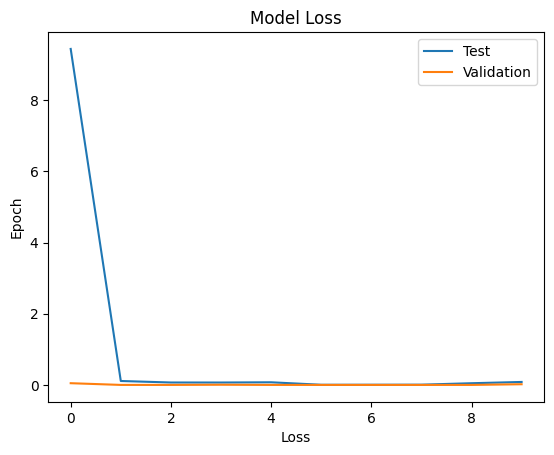

In [30]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Loss')
plt.ylabel('Epoch')
plt.legend(['Test','Validation'],loc='upper right')
plt.show()

In [48]:
from keras.wrappers.scikit_learn import KerasClassifier
#from scikeras.wrappers import SciKerasClassifier
from sklearn.model_selection import GridSearchCV
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import  Adam, SGD, RMSprop

# Define your CNN model as a function
def create_model(filters, kernel_size, dropout_rate, learning_rate,optimizer):

    model = Sequential()

    model.add(Conv2D(filters[0],kernel_size=kernel_size[0],input_shape = (128,128,3),padding = 'Same'))
    model.add(Conv2D(filters[0],kernel_size=kernel_size[0],activation='relu',padding = 'Same'))

    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(dropout_rate[0]))

    model.add(Conv2D(filters[1],kernel_size=kernel_size[1],activation='relu',padding = 'Same'))
    model.add(Conv2D(filters[1],kernel_size=kernel_size[1],activation='relu',padding = 'Same'))

    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2),strides = (2,2)))
    model.add(Dropout(dropout_rate[1]))

    model.add(Flatten())
          
    model.add(Dense(512,activation = 'relu'))
    model.add(Dropout(0.5))
    model.add(Dense(4,activation='softmax'))

    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

# Create KerasClassifier
model = KerasClassifier(build_fn=create_model,verbose=2)

# Define the hyperparameters grid
param_grid = {
    'filters': [(32, 64),(32,64)],
    'kernel_size': [((2, 2), (4, 4)),((2, 2), (4, 4))],
    'dropout_rate': [(0.25, 0.5,0.125),(0.25, 0.5,0.125)],
    'learning_rate': [0.001, 0.01,0.05],
    'optimizer': ['adam', 'rmsprop','sgd'],
    'batch_size': [32, 64],
    'epochs': [10, 20]
}

# Perform GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3,varbose=2)
grid_result = grid.fit(x_train, y_train)  # Provide your training data here

# Summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))
 

c:\Users\KIIT\anaconda3\envs\harsh\lib\site-packages\ipykernel_launcher.py:44: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.


In [ ]:
results_df = pd.DataFrame(grid_result.cv_results_)

# Save the results to a CSV file
results_df.to_csv('C:\\Users\\KIIT\\Desktop\\Work\\Projects\\form\\Myproject\\ML\\grid_search_results.csv', index=False)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification

# Create a function that returns a Keras model
def create_model():
    model = Sequential()
    filters=32
    kernel_size=(2,2)
    dropout_rate=0.25
    learning_rate=0.001
    model.add(Conv2D(filters,kernel_size=kernel_size,input_shape = (128,128,3),padding = 'Same'))
    model.add(Conv2D(filters,kernel_size=kernel_size,activation='relu',padding = 'Same'))

    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(dropout_rate))

    model.add(Conv2D(filters,kernel_size=kernel_size,activation='relu',padding = 'Same'))
    model.add(Conv2D(filters,kernel_size=kernel_size,activation='relu',padding = 'Same'))

    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2),strides = (2,2)))
    model.add(Dropout(dropout_rate))

    model.add(Flatten())
          
    model.add(Dense(512,activation = 'relu'))
    model.add(Dropout(0.5))
    model.add(Dense(4,activation='softmax'))

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model


# Create a SciKerasClassifier
model = KerasClassifier(build_fn=create_model, epochs=10, batch_size=10, verbose=1)

# Generate some example data
X, y = make_classification(n_samples=100, n_features=20, n_classes=2)

# Evaluate the model using cross-validation
scores = cross_val_score(model, x_train, y_train, cv=10)
print("Accuracy: {:.2f} (+/- {:.2f})".format(scores.mean(), scores.std()))
